# AI-Based Smart Power Usage Prediction System

## Abstract
This notebook implements a smart electricity forecasting prototype that predicts the **next 6-hour average power demand**, compares deep and baseline models, uses a **weighted ensemble** for robust accuracy, and predicts the **next-day peak hour** for backup power scheduling.

## Objectives
- Build a reliable 6-hour-ahead forecasting model
- Compare deep learning, baseline, and weighted ensemble regressors
- Track MAE, RMSE, R², RAE, and Relative Accuracy
- Predict which hour is likely to be the day’s peak load for operational planning

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

In [ ]:
# If needed, install dataset helper package
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# UCI dataset: Individual Household Electric Power Consumption
dataset = fetch_ucirepo(id=235)
raw_df = dataset.data.features.copy()

print(f"Dataset: {dataset.metadata['name']}")
print(f"Raw shape: {raw_df.shape}")
raw_df.head()

{'uci_id': 235, 'name': 'Individual Household Electric Power Consumption', 'repository_url': 'https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption', 'data_url': 'https://archive.ics.uci.edu/static/public/235/data.csv', 'abstract': 'Measurements of electric power consumption in one household with a one-minute sampling rate over a period of almost 4 years. Different electrical quantities and some sub-metering values are available.', 'area': 'Physics and Chemistry', 'tasks': ['Regression', 'Clustering'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 2075259, 'num_features': 9, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2006, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C58K54', 'creators': ['Georges Hebrail', 'Alice Berard'], 'intro_paper': None, 'additional_info': {'summary': 'This archiv

In [ ]:
DATASET_NAME = "household_power_consumption.csv"
candidate_paths = [
    Path(f"./data/{DATASET_NAME}"),
    Path(f"./AI/data/{DATASET_NAME}"),
    Path(f"/home/temi/Documents/ML/AI/data/{DATASET_NAME}"),
    Path(f"/content/{DATASET_NAME}"),
]

for p in candidate_paths:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError("Could not locate household_power_consumption.csv")

raw_df = pd.read_csv(data_path, sep=";", na_values=["?"])
print(f"Loaded data from: {data_path}")
print(f"Shape: {raw_df.shape}")
raw_df.head()

Loaded data from: data/household_power_consumption.csv
Shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df = raw_df.copy()

numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce",
)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=["datetime", "Global_active_power", "Voltage", "Global_intensity"]
)
df = df.sort_values("datetime")

df_hourly = (
    df.set_index("datetime")[["Global_active_power", "Voltage", "Global_intensity"]]
    .resample("h")
    .mean()
    .dropna()
)

print("Hourly dataset shape:", df_hourly.shape)
df_hourly.head()

Hourly dataset shape: (34168, 3)


,Global_active_power,Voltage,Global_intensity
datetime,,,
2006-12-16 17:00:00,4.222889,234.643889,18.100000
2006-12-16 18:00:00,3.632200,234.580167,15.600000
2006-12-16 19:00:00,3.400233,233.232500,14.503333
2006-12-16 20:00:00,3.268567,234.071500,13.916667
2006-12-16 21:00:00,3.056467,237.158667,13.046667


In [ ]:
FORECAST_HORIZON = 6

model_df = df_hourly.copy()

# Target: average demand over next 6 hours
future_power = pd.concat(
    [
        model_df["Global_active_power"].shift(-step)
        for step in range(1, FORECAST_HORIZON + 1)
    ],
    axis=1,
)
model_df["target_next_6h_avg"] = future_power.mean(axis=1)

# Time features
model_df["hour"] = model_df.index.hour
model_df["day_of_week"] = model_df.index.dayofweek
model_df["day_of_year"] = model_df.index.dayofyear
model_df["month"] = model_df.index.month
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24.0)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24.0)

# Lag features
for lag in [1, 2, 3, 6, 12, 24, 48]:
    model_df[f"power_lag_{lag}"] = model_df["Global_active_power"].shift(lag)
    model_df[f"voltage_lag_{lag}"] = model_df["Voltage"].shift(lag)
    model_df[f"current_lag_{lag}"] = model_df["Global_intensity"].shift(lag)

# Rolling statistics
for window in [3, 6, 12, 24]:
    model_df[f"power_roll_mean_{window}"] = (
        model_df["Global_active_power"].rolling(window).mean()
    )
    model_df[f"power_roll_std_{window}"] = (
        model_df["Global_active_power"].rolling(window).std()
    )
    model_df[f"current_roll_mean_{window}"] = (
        model_df["Global_intensity"].rolling(window).mean()
    )

model_df = model_df.dropna()
print("Model-ready shape:", model_df.shape)
model_df.head()

Model-ready shape: (34119, 44)


,Global_active_power,Voltage,Global_intensity,target_next_6h_avg,hour,day_of_week,day_of_year,month,is_weekend,hour_sin,hour_cos,power_lag_1,voltage_lag_1,current_lag_1,power_lag_2,voltage_lag_2,current_lag_2,power_lag_3,voltage_lag_3,current_lag_3,power_lag_6,voltage_lag_6,current_lag_6,power_lag_12,voltage_lag_12,current_lag_12,power_lag_24,voltage_lag_24,current_lag_24,power_lag_48,voltage_lag_48,current_lag_48,power_roll_mean_3,power_roll_std_3,current_roll_mean_3,power_roll_mean_6,power_roll_std_6,current_roll_mean_6,power_roll_mean_12,power_roll_std_12,current_roll_mean_12,power_roll_mean_24,power_roll_std_24,current_roll_mean_24
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-12-18 17:00:00,2.154900,238.729167,8.993333,2.253900,17,0,352,12,0,-0.965926,-2.588190e-01,1.949300,242.380667,8.096667,1.784300,242.423500,7.310000,1.733033,242.196500,7.096667,1.561933,239.771000,6.470000,0.293500,245.253167,1.293333,3.406767,234.229833,14.510000,4.222889,234.643889,18.100000,1.962833,0.185670,8.133333,1.843278,0.177525,7.613889,1.725261,0.461894,7.161944,1.590439,1.021879,6.681250
2006-12-18 18:00:00,2.402533,236.668500,10.083333,1.993000,18,0,352,12,0,-1.000000,-1.836970e-16,2.154900,238.729167,8.993333,1.949300,242.380667,8.096667,1.784300,242.423500,7.310000,1.756067,242.580000,7.246667,0.610000,245.704333,2.600000,3.697100,234.372333,15.750000,3.632200,234.580167,15.600000,2.168911,0.226941,9.057778,1.951022,0.280387,8.086667,1.874639,0.342973,7.785556,1.536499,0.936439,6.445139
2006-12-18 19:00:00,2.614500,235.329167,11.190000,1.616089,19,0,352,12,0,-0.965926,2.588190e-01,2.402533,236.668500,10.083333,2.154900,238.729167,8.993333,1.949300,242.380667,8.096667,1.682067,241.954167,6.940000,2.450433,240.962333,10.220000,2.908400,233.195667,12.516667,3.400233,233.232500,14.503333,2.390644,0.230031,10.088889,2.106428,0.351011,8.795000,1.888311,0.370202,7.866389,1.524253,0.919487,6.389861
2006-12-18 20:00:00,3.050567,234.524333,13.046667,1.162200,20,0,352,12,0,-0.866025,5.000000e-01,2.614500,235.329167,11.190000,2.402533,236.668500,10.083333,2.154900,238.729167,8.993333,1.733033,242.196500,7.096667,2.082133,237.880333,8.726667,3.361500,236.426500,14.276667,3.268567,234.071500,13.916667,2.689200,0.330412,11.440000,2.326017,0.464479,9.786667,1.969014,0.499332,8.226389,1.511297,0.894320,6.338611
2006-12-18 21:00:00,2.169733,237.590833,9.240000,0.851961,21,0,352,12,0,-0.707107,7.071068e-01,3.050567,234.524333,13.046667,2.614500,235.329167,11.190000,2.402533,236.668500,10.083333,1.784300,242.423500,7.310000,1.629333,237.404667,6.816667,3.040767,239.104167,12.716667,3.056467,237.158667,13.046667,2.611600,0.440424,11.158889,2.390256,0.396210,10.108333,2.014047,0.490198,8.428333,1.475004,0.845917,6.193750


In [ ]:
def relative_absolute_error(y_true, y_pred):
    den = np.abs(y_true - np.mean(y_true)).sum()
    if den == 0:
        return 0.0
    num = np.abs(y_true - y_pred).sum()
    return float(num / den)


target_col = "target_next_6h_avg"
feature_cols = [c for c in model_df.columns if c != target_col]

X = model_df[feature_cols]
y = model_df[target_col]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = model_df.index[split_idx:]

# small validation split used only for ensemble weights
val_split_idx = int(len(X_train) * 0.8)
X_fit, X_val = X_train.iloc[:val_split_idx], X_train.iloc[val_split_idx:]
y_fit, y_val = y_train.iloc[:val_split_idx], y_train.iloc[val_split_idx:]

models = {
    "Linear Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "MLP Compact": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                MLPRegressor(
                    hidden_layer_sizes=(64, 32),
                    activation="relu",
                    max_iter=500,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "MLP Deep": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                MLPRegressor(
                    hidden_layer_sizes=(128, 64, 32),
                    activation="relu",
                    max_iter=600,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=350,
        learning_rate=0.03,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

results = []
predictions = {}
fitted_models = {}
validation_rmse = {}

for name, model in models.items():
    model.fit(X_fit, y_fit)
    y_val_pred = model.predict(X_val)
    validation_rmse[name] = np.sqrt(mean_squared_error(y_val, y_val_pred))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rae = relative_absolute_error(y_test.values, y_pred)
    results.append(
        {
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "RAE": rae,
            "Relative_Accuracy": 1.0 - rae,
        }
    )
    predictions[name] = y_pred
    fitted_models[name] = model

# Weighted ensemble (inverse validation RMSE)
inv_errors = {k: 1.0 / max(v, 1e-8) for k, v in validation_rmse.items()}
inv_total = sum(inv_errors.values())
ensemble_weights = {k: v / inv_total for k, v in inv_errors.items()}

ensemble_pred = np.zeros(len(y_test), dtype=float)
for model_name, y_pred in predictions.items():
    ensemble_pred += ensemble_weights[model_name] * y_pred

ensemble_rae = relative_absolute_error(y_test.values, ensemble_pred)
results.append(
    {
        "Model": "Weighted Ensemble",
        "MAE": mean_absolute_error(y_test, ensemble_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, ensemble_pred)),
        "R2": r2_score(y_test, ensemble_pred),
        "RAE": ensemble_rae,
        "Relative_Accuracy": 1.0 - ensemble_rae,
    }
)

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
best_model_name = results_df.loc[0, "Model"]

if best_model_name == "Weighted Ensemble":
    best_pred = ensemble_pred
else:
    best_pred = predictions[best_model_name]

comparison_df = pd.DataFrame(
    {
        "datetime": dates_test,
        "actual": y_test.values,
        "predicted": best_pred,
    }
).set_index("datetime")

print("Best model:", best_model_name)
print("\nEnsemble weights:")
print(pd.Series(ensemble_weights).sort_values(ascending=False))
results_df

Best model: Weighted Ensemble

Ensemble weights:
Gradient Boosting    0.273661
MLP Compact          0.245002
MLP Deep             0.243958
Linear Regression    0.237379
dtype: float64


,Model,MAE,RMSE,R2,RAE,Relative_Accuracy
0,Weighted Ensemble,0.269823,0.365327,0.513405,0.628587,0.371413
1,Gradient Boosting,0.271380,0.365792,0.512166,0.632214,0.367786
2,MLP Compact,0.289475,0.394924,0.431367,0.674368,0.325632
3,MLP Deep,0.292908,0.402908,0.408145,0.682367,0.317633
4,Linear Regression,0.329486,0.420042,0.356736,0.767579,0.232421


## Model Evaluation and Forecast Validation

The chart below compares actual and predicted values for the hold-out set using the selected best model. Metrics include error (`MAE`, `RMSE`, `RAE`) and goodness-of-fit (`R²`, `Relative_Accuracy = 1 - RAE`).

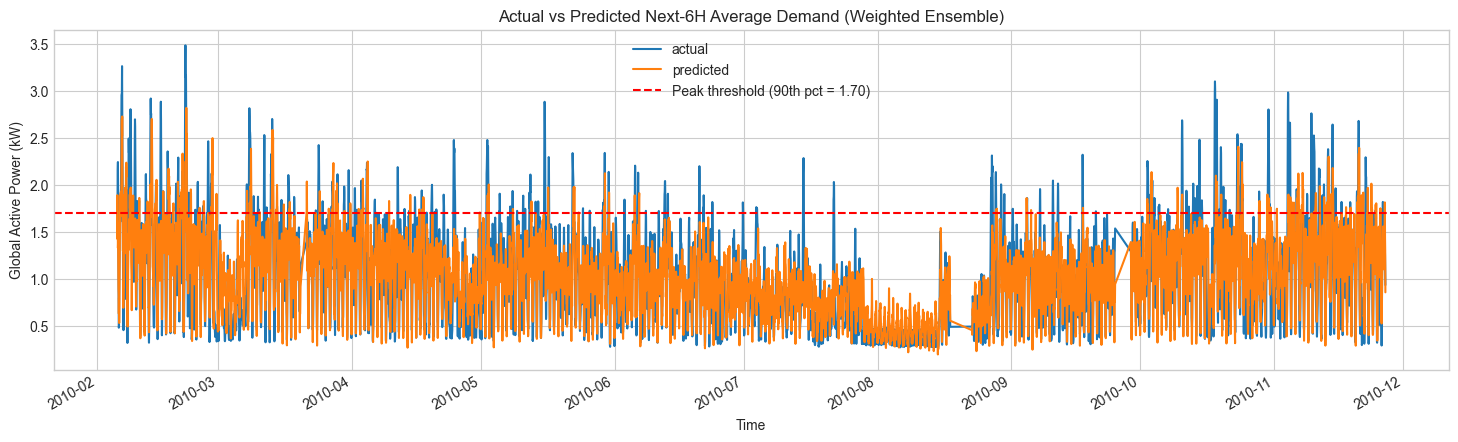

,Model,MAE,RMSE,R2,RAE,Relative_Accuracy
0,Weighted Ensemble,0.269823,0.365327,0.513405,0.628587,0.371413
1,Gradient Boosting,0.271380,0.365792,0.512166,0.632214,0.367786
2,MLP Compact,0.289475,0.394924,0.431367,0.674368,0.325632
3,MLP Deep,0.292908,0.402908,0.408145,0.682367,0.317633
4,Linear Regression,0.329486,0.420042,0.356736,0.767579,0.232421


In [8]:
peak_threshold = comparison_df["actual"].quantile(0.90)

fig, ax = plt.subplots(figsize=(18, 5))
comparison_df[["actual", "predicted"]].plot(ax=ax)
ax.axhline(
    peak_threshold,
    color="red",
    linestyle="--",
    label=f"Peak threshold (90th pct = {peak_threshold:.2f})",
)
ax.set_title(f"Actual vs Predicted Next-6H Average Demand ({best_model_name})")
ax.set_ylabel("Global Active Power (kW)")
ax.set_xlabel("Time")
ax.legend()
plt.show()

results_df

## Peak-Demand Detection + Next-Day Peak-Hour Prediction

We flag high-load periods (90th percentile threshold) and train a daily classifier to estimate the **hour most likely to peak next day**. This supports backup power scheduling decisions.

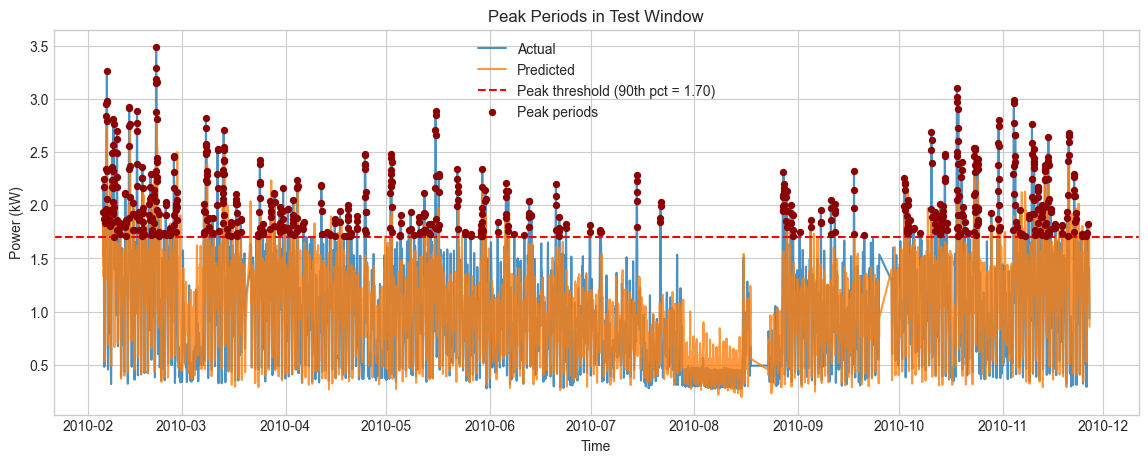

Detected peak periods: 683
Daily peak-hour classifier accuracy: 0.175
Recommended backup window (next day): 20:00 - 20:59


,actual_peak_hour,predicted_peak_hour
date,,
2010-02-08,21,13
2010-02-09,19,7
2010-02-10,21,7
2010-02-11,19,7
2010-02-12,7,20
2010-02-13,14,18
2010-02-14,19,19
2010-02-15,20,19
2010-02-16,7,7


In [ ]:
# 1) Peak periods in test window
peak_periods = comparison_df[comparison_df["actual"] >= peak_threshold].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(comparison_df.index, comparison_df["actual"], label="Actual", alpha=0.8)
ax.plot(comparison_df.index, comparison_df["predicted"], label="Predicted", alpha=0.8)
ax.axhline(
    peak_threshold,
    color="red",
    linestyle="--",
    label=f"Peak threshold (90th pct = {peak_threshold:.2f})",
)

if not peak_periods.empty:
    ax.scatter(
        peak_periods.index,
        peak_periods["actual"],
        color="darkred",
        s=18,
        label="Peak periods",
        zorder=4,
    )

ax.set_title("Peak Periods in Test Window")
ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
ax.legend()
plt.show()

print(f"Detected peak periods: {len(peak_periods)}")

# 2) Daily peak-hour prediction model
daily_df = (
    df_hourly.assign(date=df_hourly.index.date)
    .groupby("date")
    .agg(
        day_mean=("Global_active_power", "mean"),
        day_max=("Global_active_power", "max"),
        day_std=("Global_active_power", "std"),
        peak_hour=("Global_active_power", lambda s: int(s.idxmax().hour)),
    )
)

daily_df.index = pd.to_datetime(daily_df.index)
daily_df["day_of_week"] = daily_df.index.dayofweek
daily_df["month"] = daily_df.index.month
daily_df["is_weekend"] = (daily_df["day_of_week"] >= 5).astype(int)

for c in ["day_mean", "day_max", "day_std"]:
    daily_df[f"prev_{c}"] = daily_df[c].shift(1)

daily_df = daily_df.dropna()
peak_feature_cols = [c for c in daily_df.columns if c != "peak_hour"]

split_daily = int(len(daily_df) * 0.8)
X_peak_train = daily_df.iloc[:split_daily][peak_feature_cols]
y_peak_train = daily_df.iloc[:split_daily]["peak_hour"]
X_peak_test = daily_df.iloc[split_daily:][peak_feature_cols]
y_peak_test = daily_df.iloc[split_daily:]["peak_hour"]

peak_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
peak_model.fit(X_peak_train, y_peak_train)

y_peak_pred = peak_model.predict(X_peak_test)
peak_hour_accuracy = accuracy_score(y_peak_test, y_peak_pred)

latest_features_daily = daily_df.iloc[-1][peak_feature_cols].to_frame().T
predicted_peak_hour_next_day = int(peak_model.predict(latest_features_daily)[0])

print(f"Daily peak-hour classifier accuracy: {peak_hour_accuracy:.3f}")
print(
    f"Recommended backup window (next day): {predicted_peak_hour_next_day:02d}:00 - {predicted_peak_hour_next_day:02d}:59"
)

pd.DataFrame(
    {
        "actual_peak_hour": y_peak_test.values,
        "predicted_peak_hour": y_peak_pred,
    },
    index=y_peak_test.index,
).head(10)

In [ ]:
latest_x = X.iloc[-1:].copy()

if best_model_name == "Weighted Ensemble":
    next_6h_pred = 0.0
    for m_name, model in fitted_models.items():
        next_6h_pred += ensemble_weights[m_name] * float(model.predict(latest_x)[0])
else:
    next_6h_pred = float(fitted_models[best_model_name].predict(latest_x)[0])

is_predicted_peak_period = next_6h_pred >= peak_threshold

summary = pd.DataFrame(
    [
        {
            "latest_timestamp": str(model_df.index[-1]),
            "best_model": best_model_name,
            "predicted_next_6h_avg_power_kw": round(next_6h_pred, 4),
            "is_predicted_peak_period": bool(is_predicted_peak_period),
            "predicted_peak_hour_next_day": int(predicted_peak_hour_next_day),
            "backup_power_time_window": f"{predicted_peak_hour_next_day:02d}:00 - {predicted_peak_hour_next_day:02d}:59",
        }
    ]
)

summary

,latest_timestamp,best_model,predicted_next_6h_avg_power_kw,is_predicted_peak_period,predicted_peak_hour_next_day,backup_power_time_window
0,2010-11-26 20:00:00,Weighted Ensemble,0.8569,False,20,20:00 - 20:59
